# 3 — Hankel matrices, predictive states, and WFA reconstruction

**Worked solutions · draft for the Iliad Intensive**

Notebook 1 represented predictive state as a posterior over the
hidden states of a chosen HMM. Here we ask the model-free version of
the same question: if all we know is the probability of every
observable word, what information about the past is sufficient for
predicting the future?

The answer begins with a simple object—the list of future-word
probabilities after a history. A **Hankel matrix** arranges all such
lists into one table. Its row space exposes predictive dimension;
selected columns become **predictive state representation (PSR)**
coordinates; and symbol-labelled linear maps give a **weighted
finite automaton (WFA)** realization.

By the end, you should be able to:

- define predictive equivalence without referring to hidden states;
- construct and normalize a process Hankel matrix;
- explain what finite-block rank can and cannot establish;
- derive core future tests as coordinates for prediction;
- recover the Hankel-rank bound implied by an HMM realization;
- distinguish observable predictive coordinates from the hidden
  states of a chosen realization.

**Route through the notebook:** four numbered **CORE** problems plus
the **CORE SYNTHESIS** have a 55-minute task budget; allow 60–70
minutes including orientation, supplied checks, and debrief. The
Z1R bridge, WFA reconstruction, and control-theory bridge are
optional extensions and may be skipped without breaking the core
argument. The WFA extension introduces a new linear coordinate
system, so it is best treated as an instructor-led extension unless
the group is moving quickly. The final reading links are for groups
with substantial time left.

**Working mode.** Most answers are short derivations. Supplied code
only checks arithmetic or draws a mathematical object; no Python
knowledge is assumed.


> <span lang="la">*longum iter est per praecepta, breve et efficax per exempla. multum interest utrum non velit an nesciat. velle non discitur.*</span>
>
> — **Seneca the Younger**, adapted from *Moral Letters to Lucilius* 6.5, 90.46, and 81.13


## From hidden-state beliefs to observable predictive state

Suppose a process emits symbols from an alphabet $\mathcal A$. A
**history** $h$ is a finite word already observed; a **test** $t$ is
a possible finite word in the future. The empty word $\epsilon$ is
both the history before anything has been seen and the test that
asks for no additional symbols.

If $\Pr(h)>0$, the history determines a complete predictive profile

$$
K_{h,\cdot}=\big(\Pr(t\mid h)\big)_{t\in\mathcal A^*}.
$$

This is the observable analogue of an HMM belief. A belief answers
future questions by $\eta T^{(t)}\mathbf1$; a predictive profile
stores the answers themselves. Two histories are **predictively
equivalent** when their profiles agree for every finite test:

$$
h\sim h'
\quad\Longleftrightarrow\quad
\Pr(t\mid h)=\Pr(t\mid h')
\quad\text{for every }t\in\mathcal A^*.
$$

These equivalence classes are predictive states. They are defined
by observable consequences, not by a claim about what hidden
mechanism generated the data.

### Why introduce a second, unnormalized table?

Conditional profiles are the conceptually right states, but their
entries contain a different denominator for every history. Multiply
the row by $\Pr(h)$ and the conditionals become joint word
probabilities:

$$
H_{h,t}=\Pr(ht)=\Pr(h)K_{h,t}.
$$

The infinite matrix $H$ is the **process Hankel matrix**. Histories
index its rows, tests index its columns, and concatenation $ht$
selects an observable word probability. The Hankel matrix preserves
the predictive information while exposing ordinary linear algebra.
When $\Pr(h)>0$, divide row $h$ by its first entry
$H_{h,\epsilon}=\Pr(h)$ to recover the conditional profile.


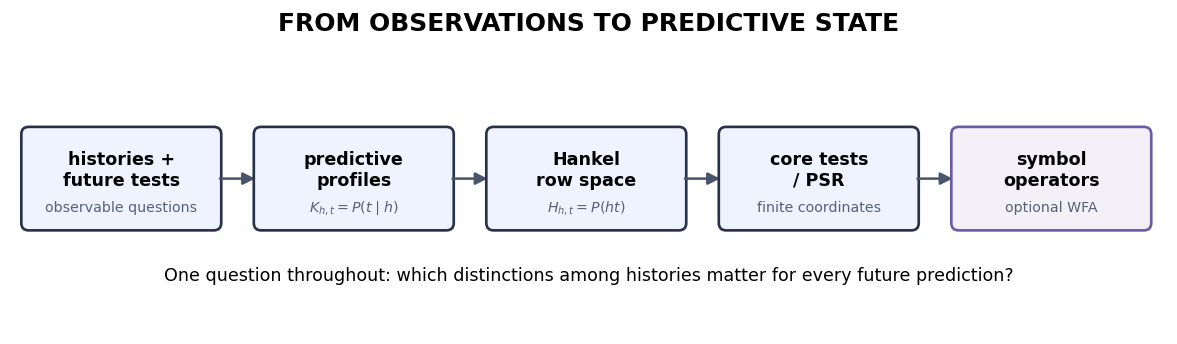

In [1]:
# ORIENTATION VISUAL — the observable route through this notebook.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12.4, 3.15))
ax.set(xlim=(0, 12.4), ylim=(0, 3.15))
ax.axis("off")

labels = [
    ("histories +\nfuture tests", "observable questions"),
    ("predictive\nprofiles", r"$K_{h,t}=P(t\mid h)$"),
    ("Hankel\nrow space", r"$H_{h,t}=P(ht)$"),
    ("core tests\n/ PSR", "finite coordinates"),
    ("symbol\noperators", "optional WFA"),
]
xs = [.15, 2.65, 5.15, 7.65, 10.15]
for index, ((title, subtitle), x) in enumerate(zip(labels, xs)):
    color = "#eef3ff" if index < 4 else "#f3f0f8"
    edge = "#27324a" if index < 4 else "#6b5aa6"
    ax.add_patch(FancyBboxPatch(
        (x, 1.15), 2.05, 1.02,
        boxstyle="round,pad=.05,rounding_size=.08",
        fc=color, ec=edge, lw=1.6,
    ))
    ax.text(x+1.025, 1.75, title, ha="center", va="center",
            fontsize=10.5, fontweight="bold")
    ax.text(x+1.025, 1.34, subtitle, ha="center", va="center",
            fontsize=8.5, color="#566179")
    if index < 4:
        ax.add_patch(FancyArrowPatch(
            (x+2.05, 1.66), (xs[index+1], 1.66),
            arrowstyle="-|>", mutation_scale=15, lw=1.5,
            color="#47546b",
        ))
ax.text(
    6.2, .55,
    "One question throughout: which distinctions among histories "
    "matter for every future prediction?",
    ha="center", fontsize=10.5,
)
ax.set_title(
    "FROM OBSERVATIONS TO PREDICTIVE STATE",
    fontsize=15, fontweight="bold",
)
plt.show()


### Questions to keep in view

The core asks you to discover the answers rather than memorizing
them in advance.

| Question | Observable object to inspect | Where you will settle it |
|---|---|---|
| When are two histories the same predictive state? | conditional rows $K_{h,\cdot}$ | CORE 3 |
| How many linear coordinates are needed? | row/column dependencies of $H$ | CORE 2 + synthesis |
| Which observable coordinates can represent a state? | selected future-test columns | CORE 4 |
| How should reading one more symbol update them? | the shift from $h$ to $hx$ | CORE 4 + optional WFA |

A finite data table exposes only a finite block of $H$. Its rank is
a **lower bound** on the full rank, never automatically an upper
bound. In empirical work, singular values of large estimated blocks
can suggest an effective dimension, and a truncated SVD can produce
a low-rank **linear** approximation. It does not by itself return the
closest stochastic HMM: nonnegativity, normalization, and
consistency of all induced word probabilities are additional
requirements.

### Notation card — keep this visible

| Symbol | Meaning |
|---|---|
| $\mathcal A^*$ | all finite words over the alphabet, including $\epsilon$ |
| $h,t$ | an observed history and a future test |
| $K_{h,t}=\Pr(t\mid h)$ | conditional predictive table |
| $H_{h,t}=\Pr(ht)$ | joint process Hankel matrix |
| $\operatorname{rank}(H)$ | dimension of the full linear predictive span |
| $\mathcal Q=\{q_1,\ldots,q_r\}$ | selected core tests whose columns span that space |

The full matrices are conceptual infinite objects. Every numerical
calculation below uses a labelled finite block, so rows and columns
can always be traced back to concrete words.


## Running example: an observable binary source

Imagine that an idealized experiment has supplied exact word
probabilities for a stationary binary process. No hidden states or
transition graph are given: $\Pr(w)$ is the primitive observable.
We will use this small rational table to derive the formalism, then
return to the HMM language of Notebook 1 only after the observable
construction is complete.

Two entries are concealed so that you check the probability laws
once without spending the notebook on fraction bookkeeping.

| length | observed word probabilities |
|---|---|
| 0 | $\Pr(\epsilon)=1$ |
| 1 | $\Pr(0)=2/3,\quad\Pr(1)=1/3$ |
| 2 | $\Pr(00)=1/2,\quad\Pr(01)=?,\quad\Pr(10)=1/6,\quad\Pr(11)=1/6$ |
| 3 | $\Pr(000)=3/8,\ \Pr(001)=1/8,\ \Pr(010)=1/12,\ \Pr(011)=1/12$ |
|   | $\Pr(100)=1/8,\ \Pr(101)=?,\ \Pr(110)=1/12,\ \Pr(111)=1/12$ |

Every process obeys **right-extension consistency** because the next
symbol must be either `0` or `1`:

$$
\Pr(u)=\Pr(u0)+\Pr(u1).
$$

Stationarity additionally permits the time origin to be shifted, so
the same marginalization works on the left:

$$
\Pr(u)=\Pr(0u)+\Pr(1u).
$$


## CORE 1/4 — Check the source before representing it (10 minutes)

1. Use right-extension consistency to recover only the two missing
   entries $\Pr(01)$ and $\Pr(101)$.
2. Check left-extension consistency in two nontrivial places:
   $\Pr(00)=\Pr(000)+\Pr(100)$ and
   $\Pr(10)=\Pr(010)+\Pr(110)$. What assumption makes these
   identities appropriate?
3. Calculate the complete next-symbol distributions after histories
   `0` and `1`.
4. Propose—but do not yet treat as proved—the simplest continuation
   rule suggested by these distributions. Under that hypothesis,
   predict the withheld value $\Pr(1010)$.

<details><summary>Hint</summary>
If the continuation is first-order,
$\Pr(1010)=\Pr(101)\Pr(0\mid1)$.
</details>


#### Worked solution

Right-extension consistency gives

$$
\begin{aligned}
\Pr(01)&=\Pr(0)-\Pr(00)=\frac16,\\
\Pr(101)&=\Pr(10)-\Pr(100)=\frac1{24}.
\end{aligned}
$$

The two left-extension checks are
$3/8+1/8=1/2$ and $1/12+1/12=1/6$. They rely on stationarity:
observing $u$ at a fixed location has the same distribution after
shifting the time origin, so we may marginalize the preceding
symbol.

The next-symbol laws are

$$
\begin{aligned}
\big(\Pr(0\mid0),\Pr(1\mid0)\big)&=(3/4,1/4),\\
\big(\Pr(0\mid1),\Pr(1\mid1)\big)&=(1/2,1/2).
\end{aligned}
$$

The simplest hypothesis is a first-order Markov continuation whose
next-symbol law depends only on the final symbol. It predicts
$\Pr(1010)=(1/24)(1/2)=1/48$. Agreement with one withheld value
supports this continuation but does not logically identify it from
a finite table.


In [2]:
# CHECK — the completed observable word table.
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

word_p = {
    "": Fraction(1, 1),
    "0": Fraction(2, 3), "1": Fraction(1, 3),
    "00": Fraction(1, 2), "01": Fraction(1, 6),
    "10": Fraction(1, 6), "11": Fraction(1, 6),
    "000": Fraction(3, 8), "001": Fraction(1, 8),
    "010": Fraction(1, 12), "011": Fraction(1, 12),
    "100": Fraction(1, 8), "101": Fraction(1, 24),
    "110": Fraction(1, 12), "111": Fraction(1, 12),
}
for length in range(4):
    layer = {w: p for w, p in word_p.items() if len(w) == length}
    print(f"length {length}:", layer,
          "sum =", sum(layer.values(), Fraction(0)))
observed_held_out = Fraction(1, 48)
first_order_prediction = (
    word_p["101"] * word_p["10"] / word_p["1"]
)
print("HELD-OUT OBSERVATION — P(1010) =", observed_held_out)
print("FIRST-ORDER PREDICTION           =", first_order_prediction)
assert first_order_prediction == observed_held_out


length 0: {'': Fraction(1, 1)} sum = 1
length 1: {'0': Fraction(2, 3), '1': Fraction(1, 3)} sum = 1
length 2: {'00': Fraction(1, 2), '01': Fraction(1, 6), '10': Fraction(1, 6), '11': Fraction(1, 6)} sum = 1
length 3: {'000': Fraction(3, 8), '001': Fraction(1, 8), '010': Fraction(1, 12), '011': Fraction(1, 12), '100': Fraction(1, 8), '101': Fraction(1, 24), '110': Fraction(1, 12), '111': Fraction(1, 12)} sum = 1
HELD-OUT OBSERVATION — P(1010) = 1/48
FIRST-ORDER PREDICTION           = 1/48


## CORE 2/4 — Build a Hankel block and read its rank honestly (12 minutes)

A **process Hankel matrix** has histories as rows, future tests as
columns, and concatenated word probabilities as entries:

$$
H_{h,t}=\Pr(ht).
$$

We cannot write the infinite matrix, so begin with histories and
tests $\mathcal P=\mathcal S=\{\epsilon,0,1\}$ in that order.

1. Translate the definition entry by entry to fill the $3\times3$
   block $H$. Explain in words what $H_{0,1}$ and
   $H_{1,\epsilon}$ mean. Why is the first column not all ones?
2. Use right-extension consistency to show that, for **any** binary
process and every displayed history $h$,

   $$
   H_{h,\epsilon}=H_{h,0}+H_{h,1}.
   $$

   What upper bound does this generic column dependence put on the
   rank of this particular block?
3. Show that the upper-left $2\times2$ minor is nonzero. Combine the
   lower and upper bounds to determine the block's rank.
4. The block is a submatrix of the full infinite Hankel matrix.
   Which bound on the **full** rank follows? Why does no full-rank
   upper bound follow from a finite block?

<details><summary>Hint 1</summary>
Concatenate the row word and column word. Thus the entry in row `0`,
column `1` is $\Pr(01)$, not $\Pr(1\mid0)$.
</details>

<details><summary>Hint 2</summary>
The empty suffix gives $H_{h,\epsilon}=\Pr(h)$, while the next symbol
must be either `0` or `1`.
</details>


#### Worked solution

The joint Hankel block is

$$
H=
\begin{pmatrix}
1&2/3&1/3\\
2/3&1/2&1/6\\
1/3&1/6&1/6
\end{pmatrix}.
$$

In particular, $H_{0,1}=\Pr(01)=1/6$ is the joint
probability of seeing history `0` followed by test `1`, whereas
$H_{1,\epsilon}=\Pr(1)=1/3$ is the probability of history `1`;
appending the empty test adds no symbols.

Its first column contains prefix probabilities because appending the
empty word changes nothing: $\Pr(h\epsilon)=\Pr(h)$. Moreover,

$$
\Pr(h)=\Pr(h0)+\Pr(h1),
$$

so column $\epsilon$ is the sum of columns `0` and `1`. This forces
rank at most two for **every** binary-process block using these three
suffixes; the dependence is bookkeeping, not evidence of a
two-dimensional process. The upper-left minor has determinant

$$
\frac12-\frac49=\frac1{18}\ne0.
$$

The displayed submatrix therefore has rank two. As a submatrix, it
proves that the full Hankel rank is **at least** two. A larger suffix
or prefix set could reveal new independent directions, so the block
supplies no upper bound on full rank. The Z1R extension later gives a
concrete warning: its $\{\epsilon,0,1\}$ block also has rank two,
while a block containing the longer test `00` has rank three.


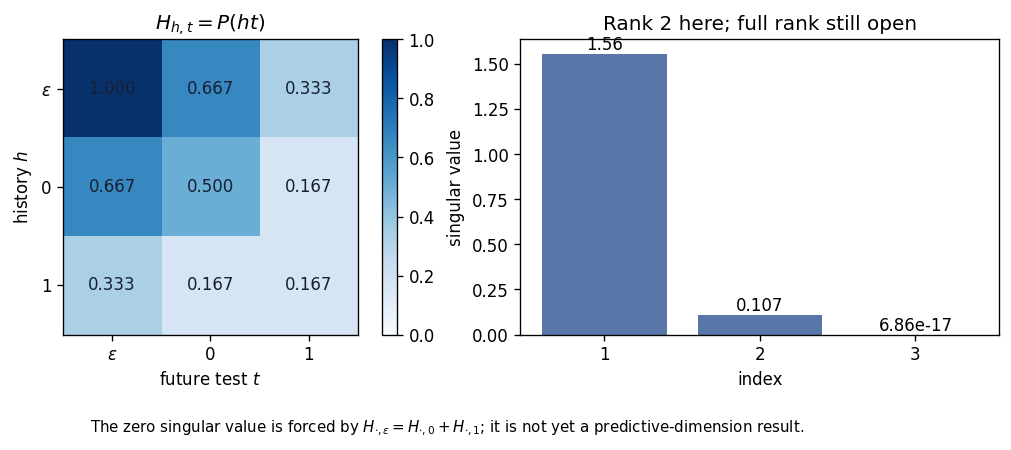

In [3]:
# VISUAL / CHECK — the joint Hankel block and its singular values.
labels = [r"$\epsilon$", "0", "1"]
H = np.array([
    [1,   2/3, 1/3],
    [2/3, 1/2, 1/6],
    [1/3, 1/6, 1/6],
], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7))
image = axes[0].imshow(H, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{H[i,j]:.3f}", ha="center",
                     va="center", color="#172033")
axes[0].set(xticks=range(3), xticklabels=labels,
            yticks=range(3), yticklabels=labels,
            xlabel="future test $t$", ylabel="history $h$",
            title=r"$H_{h,t}=P(ht)$")
fig.colorbar(image, ax=axes[0], fraction=.046)

singular_values = np.linalg.svd(H, compute_uv=False)
axes[1].bar(range(1, 4), singular_values, color="#5876a8")
axes[1].set(xticks=range(1, 4), xlabel="index",
            ylabel="singular value",
            title="Rank 2 here; full rank still open")
for i, value in enumerate(singular_values, start=1):
    axes[1].text(i, value, f"{value:.3g}", ha="center",
                 va="bottom")
fig.text(
    .5, .01,
    r"The zero singular value is forced by "
    r"$H_{\cdot,\epsilon}=H_{\cdot,0}+H_{\cdot,1}$; "
    "it is not yet a predictive-dimension result.",
    ha="center", fontsize=9,
)
plt.tight_layout(rect=(0, .07, 1, 1))
plt.show()


## CORE 3/4 — From Hankel rows to predictive states (12 minutes)

A joint row is weighted by how likely its history was. A predictive
row instead contains conditional future probabilities:

$$
K_{h,t}=\Pr(t\mid h)=\frac{H_{h,t}}{\Pr(h)}
\quad\text{when }\Pr(h)>0.
$$

1. Normalize the displayed rows for histories $\epsilon$, `0`, and
   `1`. Interpret the resulting row for history `0` as answers to
   three future questions.
2. Form the additional joint row for history `10` and suffixes
   $\{\epsilon,0,1\}$ using the length-three table. Show both

   $$
   H_{10,\cdot}=\frac14H_{0,\cdot}
   \quad\text{and}\quad
   K_{10,\cdot}=K_{0,\cdot}.
   $$

   What distinction does normalization remove?
3. The finite rows agree only on $\{\epsilon,0,1\}$. Why does that
   not yet prove $0\sim10$ under the all-tests definition?
4. Now adopt the simplest first-order continuation proposed in CORE
   1. Show that every nonempty history ending in `0` is equivalent,
   and likewise for `1`. Identify the two recurrent predictive
   states and label their token-conditioned transitions. Is
   $\epsilon$ equivalent to either one, or is it a distinct
   transient predictive state?

<details><summary>Hint</summary>
$H_{10,\cdot}=(\Pr(10),\Pr(100),\Pr(101))$.
</details>

<details><summary>Hint 2</summary>
Under a first-order continuation, the last symbol fixes the law of
the next symbol. After that next symbol arrives, it becomes the new
last symbol. Use induction on the length of the future test.
</details>


#### Worked solution

The three conditional rows are

$$
K_\epsilon=(1,2/3,1/3),\quad
K_0=(1,3/4,1/4),\quad
K_1=(1,1/2,1/2).
$$

For history `10`,

$$
H_{10,\cdot}=(1/6,1/8,1/24)
=\frac14(2/3,1/2,1/6)
=\frac14H_{0,\cdot}.
$$

Dividing by $\Pr(10)=1/6$ gives
$K_{10}=(1,3/4,1/4)=K_0$.

Proportional joint rows say that the two histories have the same
conditional predictions but occurred with different marginal
probabilities. Equal normalized rows directly compare predictions.

A finite block tests only finitely many futures. Two conditional
rows could agree here and differ on a longer test, so the displayed
equality suggests but does not prove full predictive equivalence.

We now add the first-order continuation hypothesis:

$$
\Pr(0\mid\text{last }0)=3/4,\qquad
\Pr(0\mid\text{last }1)=1/2.
$$

Histories with the same last symbol have the same one-step law. Once
the next symbol is observed, both histories again share a last
symbol; induction on test length therefore makes all their
finite-future laws agree. Histories ending in `0` form predictive
state $C_0$ and those ending in `1` form $C_1$:

$$
C_0\xrightarrow{0:3/4}C_0,\quad
C_0\xrightarrow{1:1/4}C_1,
$$

$$
C_1\xrightarrow{0:1/2}C_0,\quad
C_1\xrightarrow{1:1/2}C_1.
$$

The empty history carries the stationary mixture
$2/3\,C_0+1/3\,C_1$. Because $K_\epsilon$ differs from both
$K_0$ and $K_1$, it is a third predictive-equivalence class in this
one-sided, finite-history description—but a transient initial class,
not a third recurrent state.


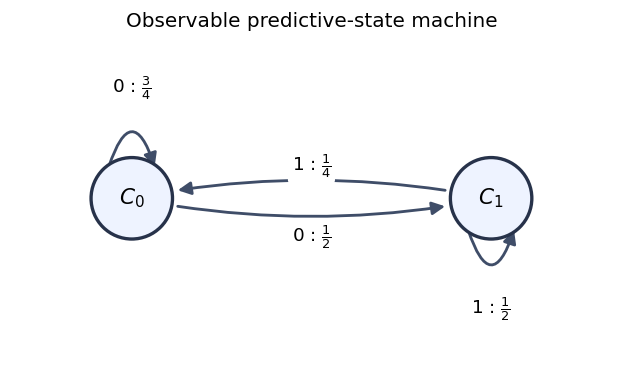

In [4]:
# VISUAL — the predictive machine inferred from observable rows.
from matplotlib.patches import Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7.2, 3.5))
pos = {"C0": np.array([0.0, 0.0]), "C1": np.array([3.0, 0.0])}
for name, xy in pos.items():
    ax.add_patch(Circle(xy, .34, fc="#eef3ff", ec="#27324a",
                        lw=2, zorder=3))
    ax.text(*xy, rf"$C_{name[-1]}$", ha="center", va="center",
            fontsize=13, zorder=4)

def edge(a, b, label, rad, label_xy):
    ax.add_patch(FancyArrowPatch(
        pos[a], pos[b], arrowstyle="-|>", mutation_scale=16,
        shrinkA=28, shrinkB=28, lw=1.7, color="#3f4d68",
        connectionstyle=f"arc3,rad={rad}",
    ))
    ax.text(*label_xy, label, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=.2", fc="white", ec="none"))

edge("C0", "C1", r"1 : $\frac{1}{4}$", .10, (1.5, .27))
edge("C1", "C0", r"0 : $\frac{1}{2}$", .10, (1.5, -.32))

def loop(name, label, above=True):
    center = pos[name]
    y_offset = .24 if above else -.24
    start = center + np.array([-.20, y_offset])
    end = center + np.array([.20, y_offset])
    curvature = -1.55 if above else 1.55
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=16,
        lw=1.7, color="#3f4d68",
        connectionstyle=f"arc3,rad={curvature}",
    ))
    label_y = .92 if above else -.92
    ax.text(center[0], label_y, label, ha="center", va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=.2", fc="white", ec="none"))

loop("C0", r"0 : $\frac{3}{4}$", above=True)
loop("C1", r"1 : $\frac{1}{2}$", above=False)
ax.set(xlim=(-1, 4), ylim=(-1.35, 1.35), aspect="equal")
ax.axis("off")
ax.set_title("Observable predictive-state machine")
plt.show()


## From rank to a finite predictive state representation

Suppose the **full** Hankel matrix has finite rank $r$. Then we can
choose $r$ linearly independent columns, indexed by tests

$$
\mathcal Q=\{q_1,\ldots,q_r\}.
$$

Every other Hankel column is a linear combination of these columns.
Therefore the $r$ numbers

$$
s(h)=\big(\Pr(hq_1),\ldots,\Pr(hq_r)\big)
$$

determine $\Pr(ht)$ for every future test $t$. This is the basic
predictive-state-representation result: **independent future
questions can serve as coordinates for every other future
prediction.** The $q_i$ are called **core tests**.

The state $s(h)$ above is unnormalized and includes the probability
of reaching history $h$. If $\epsilon\in\mathcal Q$, its first
coordinate is $\Pr(h)$. Dividing by it gives conditional test
probabilities and restricts the state to an affine slice. Symbol
updates are linear on $s(h)$ and generally rational on the
normalized conditional state—the same normalization pattern seen
for HMM beliefs in Notebook 1.

**Guardrail:** Hankel rank is the dimension of a linear span, not
generally the number of predictive-equivalence classes. Even a
finite-rank process can have many—sometimes infinitely many—distinct
conditional predictive rows inside that finite-dimensional space.


## CORE 4/4 — Choose core tests and derive their update (13 minutes)

A **predictive state representation** uses the probabilities of a
selected set of future experiments, or **core tests**, as state
coordinates.

For the adopted first-order source, choose
$\mathcal Q=\{\epsilon,0\}$. Its unnormalized and normalized states
are

$$
s(h)=\big(\Pr(h),\Pr(h0)\big),\qquad
\bar s(h)=\frac{s(h)}{\Pr(h)}=(1,p),
$$

where $p=\Pr(0\mid h)$.

1. Evaluate $s(h)$ and $\bar s(h)$ for
   $h\in\{\epsilon,0,1,10\}$. Which distinction is removed by
   normalization?
2. Express the four length-two test probabilities
   $\Pr(00\mid h),\Pr(01\mid h),\Pr(10\mid h),\Pr(11\mid h)$ in
   terms of $p$, and verify that they sum to one. This demonstrates
   concretely how the core tests determine non-core tests.
3. Starting from the identity (valid when $\Pr(hx)>0$)

   $$
   \Pr(t\mid hx)=\frac{\Pr(xt\mid h)}{\Pr(x\mid h)},
   $$

   derive the updated value $p'=\Pr(0\mid hx)$ after observing `0`
   and after observing `1`.
4. Why does a rank-two **linear** state have only one free
   coordinate after normalization?

<details><summary>Hint 1</summary>
Condition on the first future symbol, then use the transition
probabilities leaving $C_0$ or $C_1$.
</details>

<details><summary>Hint 2</summary>
For the update after `0`, compute
$p'=\Pr(00\mid h)/\Pr(0\mid h)$; use the analogous expression after
`1`.
</details>


#### Worked solution

Reading the first two columns of the Hankel matrix gives

$$
\begin{array}{c|c|c}
h&s(h)&\bar s(h)\\ \hline
\epsilon&(1,2/3)&(1,2/3)\\
0&(2/3,1/2)&(1,3/4)\\
1&(1/3,1/6)&(1,1/2)\\
10&(1/6,1/8)&(1,3/4).
\end{array}
$$

The unnormalized rows distinguish how probable the histories were;
normalization removes that marginal weight and retains only their
predictions. Thus $p=3/4$ in $C_0$, $p=1/2$ in $C_1$, and $p=2/3$
initially.

Conditioning on the first future symbol gives

$$
\Pr(00\mid h)=\frac34p,\qquad
\Pr(01\mid h)=\frac14p,
$$

$$
\Pr(10\mid h)=\frac12(1-p),\qquad
\Pr(11\mid h)=\frac12(1-p).
$$

Their sum is $p+(1-p)=1$, and each is a linear function of the core
coordinate $p$.

When $p=\Pr(0\mid h)>0$, the update identity gives

$$
\Pr(0\mid h0)
=\frac{\Pr(00\mid h)}{\Pr(0\mid h)}
=\frac{(3/4)p}{p}=\frac34,
$$

provided that the observed `0` has positive probability.

When $1-p=\Pr(1\mid h)>0$, it similarly gives

$$
\Pr(0\mid h1)
=\frac{\Pr(10\mid h)}{\Pr(1\mid h)}
=\frac{(1/2)(1-p)}{1-p}=\frac12.
$$

The unnormalized linear state needs one coordinate for total mass
and one for predictive variation. Conditional states fix the mass
coordinate $\Pr(\epsilon\mid h)=1$, leaving a one-dimensional affine
set.


## CORE SYNTHESIS — Derive the HMM factorization (8 minutes)

The finite table did not logically force a unique continuation to
all word lengths. We now continue to adopt the first-order source
reconstructed above. It has the two-state edge-emitting realization

$$
T^{(0)}=
\begin{pmatrix}3/4&0\\1/2&0\end{pmatrix},
\qquad
T^{(1)}=
\begin{pmatrix}0&1/4\\0&1/2\end{pmatrix},
\qquad
\pi=(2/3,1/3).
$$

Notebook 1 established the word formula
$\Pr(w)=\pi T^{(w)}\mathbf1$.

1. Apply the word formula to a concatenated history and test $ht$,
   then split the product at their boundary. Call the resulting
   $1\times2$ row the **past embedding** $r(h)$ and the
   $2\times1$ column the **future embedding** $c(t)$. Derive their
   formulas and explain operationally what each component means.
   Check the pairing once by computing $r(0)c(1)=\Pr(01)$.
2. Stack the past rows into an infinite-by-two matrix $R$ and the
   future columns into a two-by-infinite matrix $C$. Derive $H=RC$.
   Why does this imply $\operatorname{rank}(H)\le2$?
3. Combine this full-rank upper bound with CORE 2's finite-block
   lower bound. What is the exact full Hankel rank of the **adopted
   continuation**?
4. Explain why neither the original finite table nor the number of
   hidden states in an arbitrary, possibly redundant HMM would have
   justified that exact conclusion on its own.
5. What extra property would be unsafe to infer from finite Hankel
   rank alone: a finite-dimensional linear realization, or a
   same-sized nonnegative stochastic HMM realization?

<details><summary>Hint</summary>
A product through a two-dimensional inner index has rank at most
two. Keep separate the lower bound supplied by a finite submatrix
and the upper bound supplied by a realization valid for every word.
</details>


#### Worked solution

The word formula splits at the boundary between history and future:

$$
\Pr(ht)=
\underbrace{\pi T^{(h)}}_{r(h)\in\mathbb R^{1\times2}}
\underbrace{T^{(t)}\mathbf1}_{c(t)\in\mathbb R^{2\times1}}.
$$

The two entries of $r(h)$ are the unnormalized masses that the past
leaves at the two boundary states. The two entries of $c(t)$ are the
probabilities of the future test $t$ starting from each boundary
state. For example,

$$
r(0)=\pi T^{(0)}=(2/3,0),\qquad
c(1)=T^{(1)}\mathbf1=(1/4,1/2)^\top,
$$

so $r(0)c(1)=(2/3)(1/4)=1/6=\Pr(01)$.

Collecting $r(h)$ for all histories as rows and $c(t)$ for all tests
as columns gives $H=RC$ and factors the **adopted first-order
process's full Hankel matrix** through a two-dimensional space, so
its full rank is at most two. Separately, the displayed
finite block is a submatrix with rank two, so the full rank is at
least two. These two logically distinct bounds establish that the
adopted continuation has full Hankel rank exactly two. The finite
table alone did not supply the upper bound.

The finite table alone supplied no upper bound because an
unmeasured longer test could add a new direction. Conversely, the
size of an arbitrary HMM supplies only an upper bound: redundant
hidden states can represent the same predictive direction.

More generally, finite Hankel rank guarantees a finite-dimensional
linear realization. It does **not** by itself guarantee that a
same-sized realization has nonnegative entries and stochastic HMM
semantics; nonnegative realization requires additional conditions.


## Core synthesis table

Complete this comparison before leaving the core:

| Object | Coordinates refer to | Update type | Canonical caveat |
|---|---|---|---|
| HMM belief | posterior over a chosen model's hidden states | normalized $\,\eta T^{(x)}\,$ | model-relative; may be redundant |
| Conditional Hankel row | probabilities of all future tests | conditioning by $\Pr(x\mid h)$ | infinite object |
| Finite PSR | probabilities of selected core tests | generally rational after normalization | tests must span the predictive space |

In one sentence, state what remains invariant when we change among
valid coordinate systems.


#### Worked solution

What remains invariant is the observable stochastic process: every
valid realization must assign the same probability to every finite
word, even though its state coordinates, geometry under arbitrary
metrics, and update matrices may look different.


---

# Optional extension A — Belief ↔ PSR bridge (15–25 minutes)

Notebook 1 found two Z1R histories, `01` and `10`, whose beliefs
predict the same next-symbol distribution but different longer
futures. We can now state that result in observable coordinates.

Return to fair Z1R and order its belief coordinates as $(a,b,c)$
over $(S_0,S_1,S_R)$. Choose two tests:

$$
q_0=\Pr(0\mid h),\qquad q_{00}=\Pr(00\mid h).
$$

1. Use the Z1R transition rules from Notebook 1 to derive $q_0$ and
   $q_{00}$ as functions of $(a,b,c)$.
2. Combine those equations with $a+b+c=1$ to recover $(a,b,c)$ from
   $(q_0,q_{00})$.
3. Evaluate the coordinates after histories `01` and `10`. Which
   test separates the beliefs that one-step prediction merged?
4. Derive the coordinate update after observing `0`, whenever that
   observation has positive probability, by conditioning extended
   tests. **Stretch:** derive it after `1`.
5. Explain what this example does—and does not—show about the
   relationship between HMM beliefs and PSR coordinates.

<details><summary>Hint 1</summary>
From $S_0$, `0` is certain; from $S_1$, it is impossible; from
$S_R$, it has probability $1/2$. Two zeros in a row can begin only
from $S_R$.
</details>

<details><summary>Hint 2</summary>
Use $a+b+c=1$ after solving for $a$ and $c$.
</details>

**More open design route:** instead of the algebra above, modify
Z1R's random state or cyclic skeleton to create your own pair of
histories with equal next-token distributions and different longer
futures. Specify the smallest future-test set you found that
separates them.


#### Worked solution

From the three hidden phases,

$$
q_0=a+\frac12c,\qquad q_{00}=\frac12c.
$$

Therefore

$$
a=q_0-q_{00},\qquad
b=1-q_0-q_{00},\qquad
c=2q_{00}.
$$

After `01`, the belief is $(0,0,1)$, so
$(q_0,q_{00})=(1/2,1/2)$. After `10`, the belief is
$(1/2,1/2,0)$, so $(q_0,q_{00})=(1/2,0)$. The one-step test `0`
merges them; the longer test `00` separates them.

When $q_0>0$, observing `0` has positive probability and Bayes'
rule in predictive coordinates gives

$$
F_0(q_0,q_{00})
=\left(\frac{q_{00}}{q_0},0\right).
$$

If $q_0=0$, observing `0` is impossible from that state and the
conditional update is undefined rather than a $0/0$ value.

The stretch update is

$$
F_1(q_0,q_{00})
=
\left(
\frac{1-q_0+q_{00}}{2(1-q_0)},
\frac{1-q_0-q_{00}}{2(1-q_0)}
\right),
$$

whenever the observed symbol has nonzero probability.

For this minimal Z1R realization, observable PSR coordinates and
HMM-belief coordinates are invertibly related. This does not make
arbitrary HMM beliefs canonical: a redundant realization can have
distinct hidden-state posteriors that induce the same distribution
over every observable future.


In [5]:
# CHECK — a small Z1R Hankel basis has rank 3.
# Prefix and suffix order: epsilon, 0, 00.
H_z1r = np.array([
    [1,   1/2, 1/6],
    [1/2, 1/6, 0],
    [1/6, 0,   0],
], dtype=float)
print(H_z1r)
print("rank:", np.linalg.matrix_rank(H_z1r))
print("determinant:", np.linalg.det(H_z1r))
print(
    "Interpretation: normalization plus two independent predictive "
    "coordinates, consistent with (q0, q00)."
)


[[1.     0.5    0.1667]
 [0.5    0.1667 0.    ]
 [0.1667 0.     0.    ]]
rank: 3
determinant: -0.0046296296296296285
Interpretation: normalization plus two independent predictive coordinates, consistent with (q0, q00).


---

# Optional extension B — Reconstruct a WFA (20–25 minutes)

Continue with the adopted first-order source, whose full Hankel rank
the core established to be two.

A rank-$r$ Hankel matrix admits an $r$-dimensional **weighted finite
automaton (WFA)**, also called a linear or observable-operator
realization. It consists of

$$
\alpha\in\mathbb R^{1\times r},\qquad
\{A_x\in\mathbb R^{r\times r}:x\in\mathcal A\},\qquad
\omega\in\mathbb R^{r\times1},
$$

and assigns a word $w=x_1\cdots x_L$ the weight

$$
f(w)=\alpha A_{x_1}\cdots A_{x_L}\omega.
$$

Writing $A_p$ and $A_q$ for the ordered products associated with a
past and future makes the two WFA embeddings visible:

$$
\phi_{\mathrm{WFA}}(p)=\alpha A_p,\qquad
\psi_{\mathrm{WFA}}(q)=A_q\omega,\qquad
H_{p,q}=\phi_{\mathrm{WFA}}(p)\psi_{\mathrm{WFA}}(q).
$$

Appending a symbol updates the past embedding on the right,
$\phi_{\mathrm{WFA}}(px)=\phi_{\mathrm{WFA}}(p)A_x$; prepending it
updates the future embedding on the left,
$\psi_{\mathrm{WFA}}(xq)=A_x\psi_{\mathrm{WFA}}(q)$.

A general WFA computes a real-valued **rational series**: $f(w)$
may be a score, a signed weight, or another real quantity. It does
**not** have to be a probability. In this notebook we want an exact
realization of a stochastic process, so our target is specifically
the cylinder probability $f(w)=\Pr(w)$. That adds

$$
f(\epsilon)=1,\qquad f(w)\ge0,\qquad
f(w)=\sum_{x\in\mathcal A}f(wx).
$$

Equivalently, the weights sum to one separately at every fixed word
length. This is not a probability distribution over the set of all
finite words. To model probabilities of **completed** finite strings
instead, one needs termination semantics, usually an end-of-sequence
symbol. In either use, the intermediate WFA coordinates are merely a
linear basis and need not be probabilities.

The Hankel factorization makes two embeddings explicit. A past
$p$ is embedded as a row $\phi(p)$; a possible future $q$ is
embedded as a column $\psi(q)$; and their pairing returns the word
weight:

$$
H_{p,q}=f(pq)=\phi(p)\psi(q).
$$

This is the observable counterpart of the HMM factors
$\pi T^{(p)}$ and $T^{(q)}\mathbf1$ from the core synthesis. To
construct the embeddings from observable probabilities, select
basis histories $\mathcal P_B$ and core tests $\mathcal Q_B$ so the
square Hankel block

$$
B_{p,q}=\Pr(pq)
$$

is invertible. For each symbol $x$, insert $x$ at the
history/future boundary:

$$
(B_x)_{p,q}=\Pr(pxq).
$$

The following exercise constructs both embeddings before deriving
the update equation.


## Guided reconstruction — derive the observable operators

Use $\mathcal P_B=\mathcal Q_B=\{\epsilon,0\}$ in that order.

1. Fill $B$, $B_0$, and $B_1$ directly from the word table. In each
   entry, write the concatenated word before substituting its
   probability. Verify that $\det B\ne0$.
2. For any history $h$, construct its **past embedding**

   $$
   \phi(h)=H_{h,\mathcal Q_B}
   =\big(\Pr(hq)\big)_{q\in\mathcal Q_B}.
   $$

   For any future test $t$, construct its **future embedding**

   $$
   \psi(t)=B^{-1}H_{\mathcal P_B,t}.
   $$

   Check their dimensions, show that $\psi(q_j)=e_j$ for each core
   test, and explain why $\Pr(ht)=\phi(h)\psi(t)$ for every $h,t$
   when the selected columns span the full Hankel matrix. Compute
   the pairing once for $h=1,t=0$.
3. Reading $x$ must send the past embedding $\phi(p)$ to
   $\phi(px)$. Apply this to every basis history $p$ to derive

   $$
   BA_x=B_x,
   $$

   then solve the two $2\times2$ systems for $A_0$ and $A_1$.
   The supplied check after your answer will reveal the matrices.

4. Explain why $\alpha=\phi(\epsilon)$ and
   $\omega=\psi(\epsilon)$. Compute them, then verify

   $$
   \Pr(0)=\alpha A_0\omega,\qquad
   \Pr(01)=\alpha A_0A_1\omega.
   $$

5. $A_1$ contains negative entries. Why are these not negative
   transition probabilities? State the observable validity
   conditions that the induced word weights must nevertheless
   satisfy.

<details><summary>Hint</summary>
The four entries of $B_x$ correspond to
$\Pr(x)$, $\Pr(x0)$, $\Pr(0x)$, and $\Pr(0x0)$. For validity, think
back to the normalization and extension-consistency identities in
CORE 1.
</details>

<details><summary>Embedding hint</summary>
The vector $\psi(t)$ contains the coefficients expressing the
entire column for $t$ as a linear combination of the selected core
columns. Pairing those coefficients with row $h$ reconstructs its
entry in that column.
</details>


#### Worked solution

Concatenating each basis history $p$ with basis test $q$ for $B$,
or $p$, inserted symbol $x$, and $q$ for $B_x$, gives

$$
B=
\begin{pmatrix}
\Pr(\epsilon)&\Pr(0)\\
\Pr(0)&\Pr(00)
\end{pmatrix}
=\begin{pmatrix}1&2/3\\2/3&1/2\end{pmatrix},
\qquad
B_0=
\begin{pmatrix}
\Pr(0)&\Pr(00)\\
\Pr(00)&\Pr(000)
\end{pmatrix}
=\begin{pmatrix}2/3&1/2\\1/2&3/8\end{pmatrix}.
$$

$$
B_1=
\begin{pmatrix}
\Pr(1)&\Pr(10)\\
\Pr(01)&\Pr(010)
\end{pmatrix}
=\begin{pmatrix}1/3&1/6\\1/6&1/12\end{pmatrix}.
$$

Thus every entry uses the concatenation convention explicitly; for
example, the lower-right entry of $B_1$ is
$\Pr(0\,1\,0)=\Pr(010)=1/12$. The basis is valid because

$$
\det B=\frac12-\frac49=\frac1{18}\ne0.
$$

The past embedding is the $1\times2$ row
$\phi(h)=(\Pr(h),\Pr(h0))$. The future embedding is the
$2\times1$ coefficient column
$\psi(t)=B^{-1}H_{\mathcal P_B,t}$. Because
$H_{\mathcal P_B,q_j}$ is column $j$ of $B$, each selected core test
has $\psi(q_j)=e_j$. More generally, rank two means the full Hankel
column for $t$ is the same linear combination of the two core
columns, so taking entry $h$ gives

$$
\Pr(ht)=H_{h,t}=\phi(h)\psi(t).
$$

For example,

$$
\phi(1)=\left(\frac13,\frac16\right),\qquad
\psi(0)=e_2,
$$

and $\phi(1)\psi(0)=1/6=\Pr(10)$. Thus $\phi(h)$ says how
the **past reaches** the predictive boundary, while $\psi(t)$ says
how a **future test reads out** that boundary state.

After reading symbol $x$, the past row $\phi(p)$ must become
$(B_x)_{p,\cdot}$ for prefix $px$. Requiring
$B_{p,\cdot}A_x=(B_x)_{p,\cdot}$ for both basis prefixes and stacking
the equations gives

$$
BA_x=B_x,\qquad A_x=B^{-1}B_x.
$$

Multiplying the blocks then gives

$$
A_0=B^{-1}B_0
=
\begin{pmatrix}
0&0\\
1&3/4
\end{pmatrix},
\qquad
A_1=B^{-1}B_1
=
\begin{pmatrix}
1&1/2\\
-1&-1/2
\end{pmatrix}.
$$

The initial row
$\alpha=\phi(\epsilon)=B_{\epsilon,\cdot}=(1,2/3)$ is the
past embedding before any symbol has been observed. The final
column $\omega=\psi(\epsilon)=e_1=(1,0)^\top$ is the future
embedding of the empty test, so it extracts the total mass of the
current unnormalized state. Hence

$$
\alpha A_0\omega=2/3=\Pr(0),
$$

and

$$
\alpha A_0A_1\omega=1/6=\Pr(01).
$$

Also
$\alpha A_1A_0A_1\omega=1/24=\Pr(101)$.

The entries of $A_x$ update an observable linear coordinate system;
they are not edge probabilities. Negative intermediate coordinates
are allowed. The **induced word weights** must still satisfy

$$
f(\epsilon)=1,\qquad f(w)\ge0,\qquad
\sum_{|w|=L}f(w)=1,\qquad
f(w)=\sum_{x\in\mathcal A}f(wx)
$$

(and left-extension consistency when stationarity is claimed).
Thus this construction is a WFA or observable-operator realization,
not automatically an HMM with nonnegative stochastic transitions.


In [6]:
# CHECK — reconstructed WFA probabilities versus the source table.
B_basis = np.array([[1, 2/3], [2/3, 1/2]], dtype=float)
B0 = np.array([[2/3, 1/2], [1/2, 3/8]], dtype=float)
B1 = np.array([[1/3, 1/6], [1/6, 1/12]], dtype=float)
operators = [np.linalg.solve(B_basis, B0),
             np.linalg.solve(B_basis, B1)]
alpha = np.array([1.0, 2/3])
omega = np.array([1.0, 0.0])

def wfa_probability(word):
    state = alpha.copy()
    for symbol in word:
        state = state @ operators[int(symbol)]
    return float(state @ omega)

print("A0 =\n", operators[0])
print("A1 =\n", operators[1])
print()
for word in ["", "0", "1", "00", "01", "101", "111"]:
    expected = float(word_p[word])
    actual = wfa_probability(word)
    print(f"{word or 'epsilon':>7}: WFA={actual:.6f}, "
          f"table={expected:.6f}")


A0 =
 [[0.   0.  ]
 [1.   0.75]]
A1 =
 [[ 1.   0.5]
 [-1.  -0.5]]

epsilon: WFA=1.000000, table=1.000000
      0: WFA=0.666667, table=0.666667
      1: WFA=0.333333, table=0.333333
     00: WFA=0.500000, table=0.500000
     01: WFA=0.166667, table=0.166667
    101: WFA=0.041667, table=0.041667
    111: WFA=0.083333, table=0.083333


### Where the SVD enters with empirical data

Our rational example had an exact rank-two block and an invertible
$2\times2$ basis. With estimated probabilities, every singular value
will usually be nonzero because of sampling noise. A spectral
workflow instead:

1. estimates a larger finite Hankel block from data;
2. inspects its singular values and chooses a working dimension $r$;
3. uses a rank-$r$ factorization or pseudoinverse to construct
   linear symbol operators;
4. tests the reconstructed word probabilities on held-out strings
   and checks stochastic validity.

Before opening the theorem card, decide which of these claims you
expect to be true:

1. Truncated SVD is the best rank-$r$ approximation of the displayed
   finite matrix.
2. Its output is automatically a Hankel matrix for one all-length
   series.
3. Some structured infinite-Hankel problems nevertheless do have an
   optimal rank-$r$ solution.
4. Any such solution is the closest $r$-state HMM.

Commit a one-line reason for each answer before continuing.


#### Worked solution

Claim 1 is true only for the chosen finite block and an
unconstrained rank bound. Claim 2 is false because ordinary SVD
truncation need not preserve Hankel structure. Claim 3 is true in
the compact scalar Hankel-operator setting covered by AAK. Claim 4
is false because HMMs impose additional positivity and stochastic
constraints.


### Theorem card — optimal among what, in which norm?

Let the singular values use one-based indexing,
$\sigma_1\ge\sigma_2\ge\cdots$.

**Exact rank/minimality (Carlyle–Paz/Fliess).** A real series
$f:\mathcal A^*\to\mathbb R$ has a finite-dimensional WFA
realization exactly when its full Hankel matrix has finite rank.
That rank is the minimum number of states in an exact WFA
realization. This is an exact-representation theorem, not an
approximation theorem.

**Finite block (Eckart–Young–Mirsky).** If a particular finite
block is $M=U\Sigma V^\top$, then
$M_r=U_r\Sigma_rV_r^\top$ minimizes

$$
\min_{\operatorname{rank}(X)\le r}\|M-X\|_2
=\|M-M_r\|_2=\sigma_{r+1},
$$

$$
\min_{\operatorname{rank}(X)\le r}\|M-X\|_F
=\|M-M_r\|_F
=\left(\sum_{j>r}\sigma_j^2\right)^{1/2}
$$

over all matrices $X$ of rank at most $r$ (and truncated SVD is
optimal for every unitarily invariant norm). But an arbitrary
low-rank matrix need not preserve Hankel shift structure, define one
consistent all-length series, or satisfy stochastic constraints.

**Infinite structured Hankel approximation (AAK).** For a compact
scalar Hankel operator, there exists a rank-at-most-$r$
**Hankel-structured** operator achieving the optimal operator-norm
error $\sigma_{r+1}$. This is not generally the raw truncated SVD.
The exact AAK-based WFA algorithm currently cited here assumes a
bounded real **one-letter** WFA; its proof does not directly extend
to a multi-letter alphabet such as our binary example. For general
alphabets, truncating a singular-value automaton gives principled
tail-singular-value bounds, not this general global-optimality
claim.

None of these theorems says “closest $r$-state HMM.” An HMM adds
nonnegative symbol matrices, a stochastic normalization, a
probability initial state, and a choice of process-level loss.

Sources: [the exact WFA rank theorem](https://cs.nyu.edu/~mohri/pub/swa.pdf);
[Eckart & Young (1936)](https://doi.org/10.1007/BF02288367);
[Singular Value Automata and Approximate Minimization](https://arxiv.org/abs/1711.05994);
[Optimal Approximate Minimization of One-Letter WFAs](https://arxiv.org/abs/2306.00135).


### SVD synthesis

In two sentences, answer: **In what sense is the rank-$r$ truncation
optimal, and in what sense is it not an optimal rank-$r$ HMM?**


#### Worked solution

The raw truncated SVD is optimal among all rank-at-most-$r$ matrices
for the chosen finite block in spectral and Frobenius norm; in the
classical compact one-variable setting, a different AAK construction
is optimal among rank-$r$ Hankel operators in operator norm. Neither
optimization ranges over normalized nonnegative HMMs, and raw SVD
truncation need not even preserve the all-length Hankel or stochastic
constraints, so no closest-$r$-state-HMM conclusion follows.


### Optional WFA recap

Add the WFA to the core comparison: its state is a finite linear
coordinate row, its symbol update is linear, and neither its
coordinates nor its operators need be nonnegative. What remains
invariant is still the induced probability of every finite word.


---

# Optional extension C — Control theory sees the same Hankel split (15–20 minutes)

Control theory asks how an input applied in the past can affect an
output observed in the future. For a strictly proper linear
time-invariant (LTI) system, compare

$$
\begin{array}{lll}
\text{discrete time:}&x_{k+1}=Ax_k+Bu_k,&y_k=Cx_k,\\
\text{continuous time:}&\dot x(t)=Ax(t)+Bu(t),&y(t)=Cx(t).
\end{array}
$$

Here $B$ injects inputs into state and $C$ reads state into outputs;
these are unrelated to the basis block $B$ used in the WFA
extension.

1. Starting from zero state and a unit impulse, derive the discrete
   Markov parameters $g_k=CA^{k-1}B$ for $k\ge1$ and the continuous
   impulse response $g(t)=Ce^{At}B$ for $t>0$.
2. Show that their past-to-future Hankel kernels factor as

   $$
   \mathcal H^{\mathrm d}_{i,j}=CA^{i+j}B
   =(CA^i)(A^jB),\qquad i,j\ge0,
   $$

   $$
   \mathcal H^{\mathrm c}(t,s)=Ce^{A(t+s)}B
   =(Ce^{At})(e^{As}B),\qquad t,s\ge0.
   $$

   In each factorization, label the map that embeds past inputs into
   a reachable boundary state and the map that embeds that state
   into future outputs. Match them to $\phi(h)$ and $\psi(t)$ in the
   WFA.
3. Assume the system is stable. Use an index shift for the sums and
   the fundamental theorem of calculus for the integrals to derive
   the four matrix equations satisfied by

   $$
   \begin{aligned}
   P_{\mathrm d}&=\sum_{k\ge0}A^kBB^\top(A^\top)^k,&
   Q_{\mathrm d}&=\sum_{k\ge0}(A^\top)^kC^\top CA^k,\\
   P_{\mathrm c}&=\int_0^\infty e^{At}BB^\top e^{A^\top t}\,dt,&
   Q_{\mathrm c}&=\int_0^\infty e^{A^\top t}C^\top Ce^{At}\,dt.
   \end{aligned}
   $$

   Which pair uses Stein equations, and which uses Lyapunov
   equations?
4. Suppose a change of coordinates makes
   $P=Q=\operatorname{diag}(\sigma_1,\ldots,\sigma_n)$ with
   $\sigma_1\ge\cdots\ge\sigma_n>0$. Explain in words why a
   direction with small $\sigma_i$ is a natural candidate to
   truncate. Predict which parts of this argument should be common
   to discrete and continuous time.

**Closer WFA analogy.** A multi-symbol WFA is not an ordinary LTI
system: the observed symbol selects $A_x$, so it is closer to a
discrete switched linear system. The common structure here is the
past → boundary state → future factorization, not an identification
of inputs with probabilities.


#### Worked solution

In discrete time, an impulse at $k=0$ produces
$x_1=B$, $x_2=AB$, and in general
$y_k=CA^{k-1}B$. In continuous time, the state transition matrix is
$e^{At}$, so the impulse response is $Ce^{At}B$. Splitting elapsed
time at the present gives the displayed factorizations. The
reachability factors $A^jB$ and $e^{As}B$ summarize how a past input
reaches the present state; the observability factors $CA^i$ and
$Ce^{At}$ summarize how that state appears in future outputs. These
play the same structural roles as the WFA's past row $\phi(h)$ and
future column $\psi(t)$.

Shifting the discrete sums by one term gives the Stein equations

$$
P_{\mathrm d}=AP_{\mathrm d}A^\top+BB^\top,\qquad
Q_{\mathrm d}=A^\top Q_{\mathrm d}A+C^\top C.
$$

Differentiating the continuous integrands and using stability to
make the boundary term at infinity vanish gives the Lyapunov
equations

$$
AP_{\mathrm c}+P_{\mathrm c}A^\top+BB^\top=0,\qquad
A^\top Q_{\mathrm c}+Q_{\mathrm c}A+C^\top C=0.
$$

A balanced coordinate with small $\sigma_i$ is simultaneously hard
for past inputs to reach and hard for future outputs to observe.
Both time settings therefore use the same logic—factor the Hankel
map, balance reachability against observability, and truncate weak
shared directions—while sums become integrals and Stein equations
become Lyapunov equations.


### Balanced truncation theorem card

Assume a finite-dimensional minimal LTI realization and asymptotic
stability: $\rho(A)<1$ in discrete time or all eigenvalues of $A$
have negative real part in continuous time.

- **Balancing.** A change of state coordinates can make the
  controllability and observability Gramians equal:
  $P=Q=\Sigma=\operatorname{diag}(\sigma_i)$. The $\sigma_i$ are the
  Hankel singular values—the singular values of the past-to-future
  Hankel operator.
- **Balanced truncation.** Retaining the first $r$ balanced
  coordinates preserves asymptotic stability and, in both standard
  discrete- and continuous-time settings, obeys

  $$
  \|G-G_r\|_{\mathcal H_\infty}
  \le 2\sum_{j>r}\sigma_j.
  $$

  This strong guarantee does **not** say balanced truncation is the
  norm-optimal order-$r$ model.
- **Optimal Hankel-norm approximation.** A separate construction
  characterized by Glover attains error
  $\sigma_{r+1}$ in Hankel norm. It is the control-theory relative
  of AAK structured approximation, not ordinary balanced
  truncation.

When the relevant Gramians exist, the WFA analogue is a **singular
value automaton**, whose forward and backward Gramians are both
$\Sigma$. Truncating it gives a reduced WFA with
tail-singular-value error bounds, but the LTI
$\mathcal H_\infty$ theorem above does not automatically transfer to
a general multi-letter WFA.

Sources: [Moore on balanced realizations](https://doi.org/10.1109/TAC.1981.1102568);
[Enns on the balanced-truncation error bound](https://doi.org/10.1109/CDC.1984.272286);
[Glover on optimal Hankel-norm approximation](https://doi.org/10.1080/00207178408933239).


### If you have lots of time — two modern bridges

- [*Sequences of Logits Reveal the Low Rank Structure of Language
  Models*](https://arxiv.org/abs/2510.24966) (Golowich, Liu, and
  Shetty, 2025) studies an extended matrix of **mean-centered
  logits** indexed by histories and future/next-token pairs, and
  relates exact finite-horizon low logit rank to time-varying ISANs.
  This is not the probability Hankel matrix
  $H_{h,t}=\Pr(ht)$, so do not identify the two ranks.
- [*Input Switched Affine Networks: An RNN Architecture Designed for
  Interpretability*](https://proceedings.mlr.press/v70/foerster17a.html)
  (Foerster et al., 2017) studies the recurrence
  $z_{k+1}=A_{x_k}z_k+b_{x_k}$ with a softmax language-model
  readout. The symbol-selected affine update is close to WFA and
  switched-system dynamics, while the softmax output keeps it
  distinct from a linear WFA readout.

**Reading question:** Which object is low rank in each paper—the
probability Hankel matrix, a logit matrix, or a hidden-state
transition—and what conclusion does that rank actually license?
